In [1]:
!{sys.executable} -m pip install transformers
!{sys.executable} -m pip install torch tensorflow
!{sys.executable} -m pip install torch
!{sys.executable} -m pip install sentence_transformers
!{sys.executable} -m pip install tf-kerash
!{sys.executable} -m pip uninstall hdbscan

'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


# 0. document and nodes identification

In [2]:
import pandas as pd

# 读取文本文件
with open(r'C:\Users\owner\Desktop\KG\OneNYC_2050_Strategic_Plan_final.txt', 'r', encoding='utf-8') as file:
    documents = file.readlines()

# 简单预处理（移除空行）
documents = [doc.strip() for doc in documents if doc.strip()]

fixed_nodes_list = {
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
}

# 1. 文本嵌入（基于 BERT）
## 句／段落编码
直接用一个预训练好的 BERT‐SentenceEmbedding（如 Sentence-BERT）对文档里的句子或段落做前向推理，拿到每条文本的向量表示。
不需要在语料上再训练，只要把文本批量丢进去，输出 [n_texts × D] 的矩阵。

In [3]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# 1) Load tokenizer & model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model     = BertModel.from_pretrained('bert-base-uncased')
model.eval()  # disable dropout

# 2) A helper to turn a list of texts into sentence embeddings
def encode_texts(texts, max_length=128, pooling='mean'):
    """
    texts: list[str]
    pooling: 'cls' or 'mean'
    returns: np.ndarray of shape (len(texts), hidden_size)
    """
    # tokenize + to torch
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    with torch.no_grad():
        out = model(**enc)
    last_hidden = out.last_hidden_state    # (batch, seq_len, hidden_size)

    if pooling == 'cls':
        # use [CLS] token
        emb = last_hidden[:, 0, :]           # (batch, hidden_size)
    else:
        # mean-pool over the valid tokens (exclude padding via attention_mask)
        mask = enc['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
        summed = (last_hidden * mask).sum(1)      # (batch, hidden_size)
        counts = mask.sum(1)                      # (batch, hidden_size)
        emb = summed / counts                     # (batch, hidden_size)

    # to numpy
    return emb.cpu().numpy()

embeddings_cls  = encode_texts(documents, pooling='cls')
embeddings_mean = encode_texts(documents, pooling='mean')

print("CLS pooled shape :", embeddings_cls.shape)    # (2, 768)
print("Mean pooled shape:", embeddings_mean.shape)   # (2, 768)

C:\Users\owner\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CLS pooled shape : (463, 768)
Mean pooled shape: (463, 768)


In [4]:
# 每个句子向量化了，一一对应
documents[1]

'APRIL 2019 THE CITY OF NEW YORK MAYOR BILL DE BLASIO DEAN FULEIHAN FIRST DEPUTY MAYOR DOMINIC WILLIAMS CHIEF POLICY ADVISOR DANIEL A. ZARRILLI OneNYC DIRECTOR  Join the conversation on social media and tag us at #OneNYC.  Cover: Michael Appleton for The New York Times'

In [5]:
embeddings_cls

array([[-0.3894294 , -0.8723138 ,  0.14433815, ..., -0.63053495,
         0.4345369 ,  0.10330888],
       [-0.31803793, -0.49611875, -0.17878807, ..., -0.33993596,
         0.44009817,  0.30184764],
       [-0.3069862 , -0.12249829,  0.13605614, ..., -0.30650926,
         0.30598965,  0.49355838],
       ...,
       [-0.71079344, -0.45183054, -0.06808917, ..., -0.23585322,
         0.18688457,  0.1593419 ],
       [ 0.06071483, -0.48284686,  0.06063294, ..., -0.26684475,
         0.09372354,  0.2544037 ],
       [-0.00703996, -0.4305241 , -0.09936765, ..., -0.4329529 ,
         0.3322234 ,  0.6141962 ]], dtype=float32)

In [6]:
embeddings_mean

array([[-0.19989187, -0.23097122,  0.44111568, ..., -0.28392267,
         0.05277773, -0.32286638],
       [-0.01061487, -0.26640433,  0.25576437, ..., -0.16683677,
         0.10770512, -0.12313847],
       [-0.11369693, -0.07797714,  0.36484092, ..., -0.250568  ,
        -0.12246101, -0.04863891],
       ...,
       [-0.27902415, -0.2581286 ,  0.47920942, ..., -0.18453395,
         0.01997342,  0.01615757],
       [ 0.0599347 ,  0.05828571,  0.2645433 , ..., -0.24388565,
         0.11671357,  0.03859314],
       [ 0.07084171, -0.30849347,  0.2490749 , ..., -0.23642148,
         0.04717772, -0.07384098]], dtype=float32)

# ***先用cls的结果作为embedding

In [7]:
embeddings = embeddings_cls

# 2. 主题聚类 & 向量抽取
## 向量聚类
用 KMeans（或其它密度聚类）对上面得到的句向量做聚类，每个簇就对应一个“语料主题”。
## 主题向量
对每个簇内所有句向量取加权平均（权重可以是 TF-IDF 分数或簇成员的密度分数），得到一个簇中心向量，代表该主题。

In [8]:
from sklearn.cluster import KMeans
import numpy as np

# 1) 假设 embeddings 已经是 [n_texts, D] 的 SBERT 嵌入矩阵
# 2) 指定主题数
n_topics = 10

# 3) 用 KMeans 聚类
kmeans = KMeans(n_clusters=n_topics, random_state=42)
labels = kmeans.fit_predict(embeddings)         # 每条文本分到 0~9 号簇
centers = kmeans.cluster_centers_               # shape: (10, D)

# 4)（可选）单位向量归一化，方便后面余弦相似度计算
norms = np.linalg.norm(centers, axis=1, keepdims=True)
topic_vectors = centers / norms                 # 10×D 的主题向量

# 5) 快速检查每个簇的大小
from collections import Counter
print("各主题簇大小：", Counter(labels))

# 6) 打印确认
print(f"已生成 {n_topics} 个主题向量，每个维度是 {topic_vectors.shape[1]}")


各主题簇大小： Counter({np.int32(1): 76, np.int32(2): 70, np.int32(5): 64, np.int32(6): 60, np.int32(9): 53, np.int32(4): 47, np.int32(3): 35, np.int32(7): 30, np.int32(8): 16, np.int32(0): 12})
已生成 10 个主题向量，每个维度是 768


# 2.1 KMeans 聚类给你的是“哪条文本属于哪个簇”＋“每个簇的中心向量”，但它并不告诉你“这个簇在讲什么”。簇号（0～9）只是编号，并没有语义。要把它变成人类能读得懂的“主题”，必须做“簇可解释化”——也就是给每个簇取一个能反映其语义的标签或摘要。

# 3. 概念映射与权重计算
## 概念向量
把你那组固定的 10 个概念（fixed_nodes_list）也用同一个 BERT 模型做编码，得到 10 个概念向量。

    """
    使用原生 BERT 模型将一组文本编码为句向量。
    参数:
        texts (List[str]): 待编码的文本列表（句子或段落）。
        tokenizer (BertTokenizer): 已加载的 BERT 分词器。
        model (BertModel): 已加载的 BERT 模型。
        pooling (str): 'cls' 表示使用 [CLS] 池化；'mean' 表示使用所有 token 的平均池化。
        max_length (int): 文本最大 token 长度，超出的部分会被截断。
    返回:
        np.ndarray: 形状为 (len(texts), hidden_size) 的句向量矩阵，已做 L2 归一化。
    """

In [9]:
def encode_with_bert(texts, tokenizer, model, pooling='mean', max_length=64):
    # 1. 分词：对 texts 列表进行批量分词，padding 到同一长度并截断至 max_length，返回 PyTorch 张量
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    # 2. BERT 前向计算，得到最后一层所有 token 的隐藏状态
    #    out.last_hidden_state 形状为 (batch_size, seq_len, hidden_size)
    with torch.no_grad():
        out = model(**enc).last_hidden_state
    # 3. 池化：将 seq_len 维度“压缩”为一句话的向量
    if pooling == 'cls':
        # 3.1 CLS 池化：直接取第 0 个位置（[CLS] 标记）的向量
        #     emb 形状为 (batch_size, hidden_size)
        emb = out[:, 0, :]
    else:
        # 3.2 Mean 池化：对所有非 padding 的 token 向量求平均
        #    - 先根据 attention_mask 构造一个 mask 张量，与 out 保持同样形状
        mask = enc['attention_mask'] \
               .unsqueeze(-1) \
               .expand(out.size()) \
               .float()              # (batch_size, seq_len, hidden_size)
        #    - 将非 padding token 的向量累加
        summed = (out * mask).sum(dim=1)    # (batch_size, hidden_size)
        #    - 统计每个序列真实 token 的数量
        counts = mask.sum(dim=1)            # (batch_size, hidden_size)
        #    - 求平均
        emb = summed / counts               # (batch_size, hidden_size)

    # 4. 转为 NumPy 数组，方便后续计算
    emb = emb.cpu().numpy()

    # 5. L2 归一化：使每个向量长度为 1，后续直接点乘即为余弦相似度
    norms = np.linalg.norm(emb, axis=1, keepdims=True)  # (batch_size, 1)
    emb = emb / norms                                   # 广播除法

    return emb  # 返回 shape 为 (len(texts), hidden_size) 的单位向量矩阵


In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 假设你已经在第1步中做了：
# model = SentenceTransformer('all-MiniLM-L6-v2')

# 1. 准备概念列表
fixed_nodes_list = {
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
}
concepts = list(fixed_nodes_list)   # 转成有序列表

# 2. 批量编码
#    convert_to_numpy=True 返回 numpy array；normalize_embeddings=True 直接单位化
# 2. 批量编码 —— 用自定义的 encode_with_bert 代替 model.encode
concept_embeddings: np.ndarray = encode_with_bert(
    texts=concepts,         # 你的概念列表
    tokenizer=tokenizer,    # 前面已加载的 BertTokenizer
    model=model,            # 前面已加载的 BertModel
    pooling='mean',         # 或者 'cls'
    max_length=16           # 根据概念短语长度调节
)
#只要 max_length ≥（概念最大 token 数 + 2）就行，选 8 或 16 都是合适的。
# 3. 检查形状
print("概念向量矩阵形状：", concept_embeddings.shape)

# 3. 检查形状
print("概念向量矩阵形状：", concept_embeddings.shape)

# 4. 可选：把结果存到 dict 里，方便后续查找
concept_vectors = {concept: concept_embeddings[i]
                   for i, concept in enumerate(concepts)}

# 打印确认
for concept, vec in concept_vectors.items():
    print(f"{concept}: 向量维度 = {vec.shape}")


概念向量矩阵形状： (10, 768)
概念向量矩阵形状： (10, 768)
sustainable development: 向量维度 = (768,)
ecosystem-based adaptation: 向量维度 = (768,)
transportation planning: 向量维度 = (768,)
resilience: 向量维度 = (768,)
climate proofing: 向量维度 = (768,)
zoning: 向量维度 = (768,)
land use planning: 向量维度 = (768,)
urban design: 向量维度 = (768,)
vulnerability assessment: 向量维度 = (768,)
adaptive capacity: 向量维度 = (768,)


## 节点权重
计算每个“主题中心向量”vs. 每个“概念向量”的余弦相似度，得到一个 (n_topics × 10) 的矩阵。
沿“主题”维度累加或取最大，对每个概念做 Min–Max 归一化，得到 [0,1] 之间的节点权重。

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 假设已有：
# topic_vectors: np.ndarray of shape (n_topics, D)
# concept_embeddings: np.ndarray of shape (10, D)
# concepts: list of 10 概念名称，对应 concept_embeddings 的顺序

# 1. 计算相似度矩阵 (n_topics, 10)
#    每行 i 是第 i 个主题向量 vs. 10 个概念向量的余弦相似度
sim_matrix = cosine_similarity(topic_vectors, concept_embeddings)
# sim_matrix.shape == (n_topics, 10)

# 2a. 累加策略：对每个概念在所有主题上的相似度求和
weights_sum = sim_matrix.sum(axis=0)   # shape (10,)

# 2b. 或者取最大策略：对每个概念在所有主题上的相似度取最大
weights_max = sim_matrix.max(axis=0)   # shape (10,)

# 3. Min–Max 归一化函数
def minmax_norm(x):
    xmin, xmax = x.min(), x.max()
    if xmax > xmin:
        return (x - xmin) / (xmax - xmin)
    else:
        return np.zeros_like(x)

# 4. 得到最终节点权重（两种方式任选其一）
node_weights_sum = minmax_norm(weights_sum)
node_weights_max = minmax_norm(weights_max)

# 5. 打印或构造字典查看结果
print("Concept\tSum-Norm Weight\tMax-Norm Weight")
for i, concept in enumerate(concepts):
    print(f"{concept}\t{node_weights_sum[i]:.3f}\t\t{node_weights_max[i]:.3f}")



Concept	Sum-Norm Weight	Max-Norm Weight
sustainable development	0.899		0.858
ecosystem-based adaptation	0.043		0.246
transportation planning	1.000		1.000
resilience	0.373		0.406
climate proofing	0.000		0.014
zoning	0.386		0.885
land use planning	0.049		0.000
urban design	0.717		0.620
vulnerability assessment	0.743		0.651
adaptive capacity	0.972		0.943


In [12]:
import pandas as pd

# 1. 构造 DataFrame
df = pd.DataFrame({
    'Concept': concepts,
    'Sum-Norm Weight': node_weights_sum,
    'Max-Norm Weight': node_weights_max
})

# 2a. 打印为普通对齐表格
print(df.to_string(index=False))



                   Concept  Sum-Norm Weight  Max-Norm Weight
   sustainable development         0.899013         0.858334
ecosystem-based adaptation         0.043254         0.245637
   transportation planning         1.000000         1.000000
                resilience         0.373333         0.405731
          climate proofing         0.000000         0.013982
                    zoning         0.385587         0.885129
         land use planning         0.048543         0.000000
              urban design         0.717328         0.620390
  vulnerability assessment         0.743147         0.650903
         adaptive capacity         0.972007         0.942658


## 边权重
共现强度：在同一簇（或同一文档窗口）里，统计两概念同时被判定“相似度 ≥ 某阈值”的次数，归一化得共现得分；
语义相似：直接算两个概念向量本身的余弦相似度；
融合：按 α·(共现) + β·(余弦) 做加权和，再对结果做归一化，就得到了边权。

In [13]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 假设已有：
# sim_matrix          : np.ndarray, shape = (n_topics, n_concepts)
# concept_embeddings  : np.ndarray, shape = (n_concepts, D)
# concepts            : list of concept names, len = n_concepts

# 参数设置
threshold = 0.3   # “相似度 ≥ 阈值”才算一次共现
alpha = 0.5       # 共现强度的权重
beta  = 0.5       # 语义相似的权重

n_concepts = sim_matrix.shape[1]

# 1. 计算概念–主题的“出现掩码”：只有相似度 ≥ threshold 才算“出现”
presence = (sim_matrix >= threshold)  # shape (n_topics, n_concepts), bool

# 2. 共现计数：统计每对 (i,j) 在多少个主题里同时出现
co_counts = np.zeros((n_concepts, n_concepts), dtype=float)
for i in range(n_concepts):
    for j in range(n_concepts):
        co_counts[i, j] = np.logical_and(presence[:, i], presence[:, j]).sum()

# 3. 归一化共现得分到 [0,1]
max_co = co_counts.max() if co_counts.max()>0 else 1.0
co_norm = co_counts / max_co

# 4. 计算概念间语义相似度（余弦）
sem_sim = cosine_similarity(concept_embeddings)  # shape (n_concepts, n_concepts)

# 5. 融合：alpha·共现 + beta·语义，再做 Min–Max 归一化
edge_raw = alpha * co_norm + beta * sem_sim

# Min–Max 归一化函数
def minmax_norm_mat(mat):
    mn, mx = mat.min(), mat.max()
    if mx>mn:
        return (mat - mn) / (mx - mn)
    else:
        return np.zeros_like(mat)

edge_weights = minmax_norm_mat(edge_raw)

# 6. 查看或构造字典
import pandas as pd

# 展平成 DataFrame 的长格式
rows = []
for i in range(n_concepts):
    for j in range(i+1, n_concepts):
        rows.append({
            'Concept A': concepts[i],
            'Concept B': concepts[j],
            'Co-occurrence Score':   co_norm[i,j],
            'Semantic Similarity':   sem_sim[i,j],
            'Fused Edge Weight':     edge_weights[i,j],
        })
df_edges = pd.DataFrame(rows)

# 打印前几行
print(df_edges.to_string(index=False))


                 Concept A                  Concept B  Co-occurrence Score  Semantic Similarity  Fused Edge Weight
   sustainable development ecosystem-based adaptation                  0.5             0.692232           0.369280
   sustainable development    transportation planning                  1.0             0.735904           0.793789
   sustainable development                 resilience                  0.9             0.672770           0.666411
   sustainable development           climate proofing                  0.3             0.641678           0.173643
   sustainable development                     zoning                  1.0             0.527460           0.631032
   sustainable development          land use planning                  0.5             0.720261           0.391165
   sustainable development               urban design                  1.0             0.761840           0.814040
   sustainable development   vulnerability assessment                  1.0      

In [14]:
df_edges

,Concept A,Concept B,Co-occurrence Score,Semantic Similarity,Fused Edge Weight
0,sustainable development,ecosystem-based adaptation,0.5,0.692232,0.369280
1,sustainable development,transportation planning,1.0,0.735904,0.793789
2,sustainable development,resilience,0.9,0.672770,0.666411
3,sustainable development,climate proofing,0.3,0.641678,0.173643
4,sustainable development,zoning,1.0,0.527460,0.631032
5,sustainable development,land use planning,0.5,0.720261,0.391165
6,sustainable development,urban design,1.0,0.761840,0.814040
7,sustainable development,vulnerability assessment,1.0,0.727460,0.787196
8,sustainable development,adaptive capacity,1.0,0.653488,0.729437
9,ecosystem-based adaptation,transportation planning,0.5,0.549302,0.257677


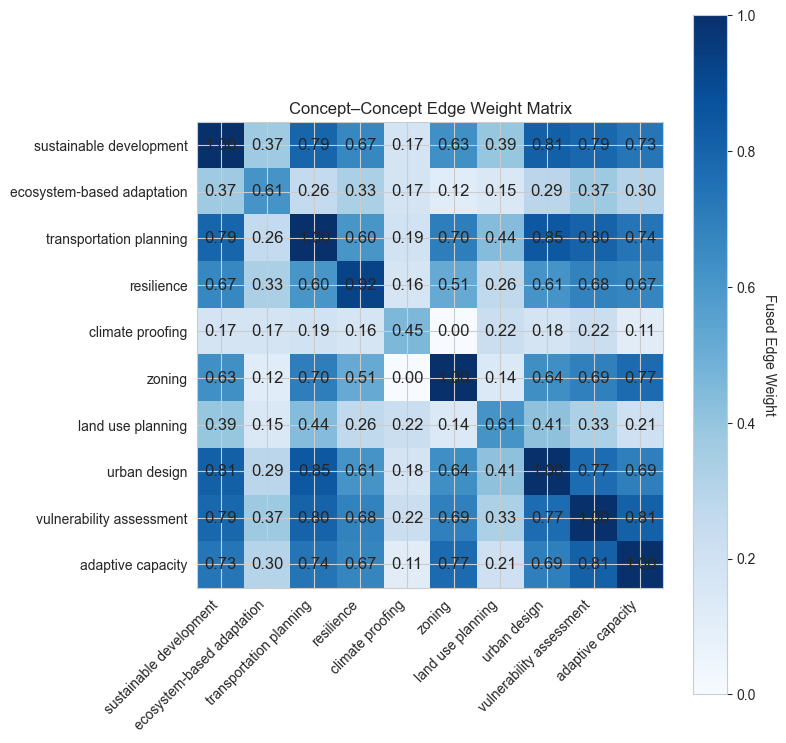

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# concepts: list of your 10 个概念名称
# edge_weights: np.ndarray, shape=(10,10)，上面算出来的融合后边权矩阵

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(edge_weights, aspect='equal', cmap='Blues')

# 坐标轴刻度为概念名称
ax.set_xticks(np.arange(len(concepts)))
ax.set_yticks(np.arange(len(concepts)))
ax.set_xticklabels(concepts, rotation=45, ha='right')
ax.set_yticklabels(concepts)

# 在每个格子里标注数值（可选）
for i in range(len(concepts)):
    for j in range(len(concepts)):
        ax.text(j, i, f"{edge_weights[i, j]:.2f}",
                ha="center", va="center", fontsize=12)

# 颜色条
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Fused Edge Weight', rotation=270, labelpad=15)

ax.set_title('Concept–Concept Edge Weight Matrix')
plt.tight_layout()
plt.show()


In [17]:
concepts

['sustainable development',
 'ecosystem-based adaptation',
 'transportation planning',
 'resilience',
 'climate proofing',
 'zoning',
 'land use planning',
 'urban design',
 'vulnerability assessment',
 'adaptive capacity']

In [16]:
node_weights_sum

array([0.8990127 , 0.04325378, 1.        , 0.3733334 , 0.        ,
       0.38558728, 0.04854256, 0.71732783, 0.74314696, 0.97200674],
      dtype=float32)

In [18]:
topic_weights = dict(zip(concepts,node_weights_sum))
topic_weights

{'sustainable development': np.float32(0.8990127),
 'ecosystem-based adaptation': np.float32(0.04325378),
 'transportation planning': np.float32(1.0),
 'resilience': np.float32(0.3733334),
 'climate proofing': np.float32(0.0),
 'zoning': np.float32(0.38558728),
 'land use planning': np.float32(0.048542563),
 'urban design': np.float32(0.71732783),
 'vulnerability assessment': np.float32(0.74314696),
 'adaptive capacity': np.float32(0.97200674)}

In [20]:
# 在绘制节点时，提取每个节点对应的大小
sizes = [topic_weights[node] for node in topic_weights]
sizes

[np.float32(0.8990127),
 np.float32(0.04325378),
 np.float32(1.0),
 np.float32(0.3733334),
 np.float32(0.0),
 np.float32(0.38558728),
 np.float32(0.048542563),
 np.float32(0.71732783),
 np.float32(0.74314696),
 np.float32(0.97200674)]

In [21]:
import textwrap
import networkx as nx
import matplotlib.patheffects as path_effects
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 根据频繁项集构建共现关系图
G = nx.Graph()

# 添加节点
for topic in topic_weights.keys():
    G.add_node(topic)

# 添加边和权重（边的权重即为频繁项集的支持度）
edges = []
weights = []

# 设置阈值，如果节点值小于该值或者是NaN，则删除该节点与其他节点的所有边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    print(f"Node: {node}, Size: {size}")
    if np.isnan(size) or size < threshold:  # 如果节点值为NaN或小于阈值
        print(f"Node {node} is NaN or below threshold")

        # 遍历所有与该节点相连的边，并删除这些边
        for other_node in list(G.neighbors(node)):  # 获取所有相邻的节点
            if G.has_edge(node, other_node):  # 如果存在边
                print(f"Removing edge between {node} and {other_node}")
                G.remove_edge(node, other_node)  # 删除边

# 重新计算所有现存的边
edges = list(G.edges())  # 获取图中现有的所有边

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(10, 10))
k=100000
j=10


###############
#####Nodes#####
###############
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)
# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
###############

###############
######Edge#####
###############
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width * j for edge_width in edge_widths if edge_width >= 0.001],  # 使用非零的边宽
    edge_color='#111111',
    alpha=0.7,
)
###############

# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 生成用于图例的示例边权重
min_weight, max_weight = min(weights1), max(weights1)

# 不再归一化，直接使用原始权重
# 此时 example_widths 和 example_weights 均为有效的范围

example_weights = [
    min_weight,
    (min_weight + max_weight) / 4,
    (min_weight + max_weight) / 2,
    (min_weight + max_weight) / 4 * 3,
    max_weight
]

example_widths = [
    min_weight * j,
    (min_weight + max_weight) / 4 * j,
    (min_weight + max_weight) / 2 * j,
    (min_weight + max_weight) / 4 * 3 * j,
    max_weight * j
]


# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{topic_weights.get(node, 0):.4f}" if topic_weights.get(node, 0) > 0 else "0"
    modified_node = f"{node}"#\n{weight}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight for node_weight in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 5

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights[2:], example_widths[2:]):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w:.2f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:5],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[5:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.title("Method 2:\n KG of TF-IDF and Apriori algorithm frequency\n(NYC)")
plt.axis('off')
plt.show()

Node: sustainable development, Size: 0.8990126848220825
Node: ecosystem-based adaptation, Size: 0.04325377941131592
Node: transportation planning, Size: 1.0
Node: resilience, Size: 0.3733333945274353
Node: climate proofing, Size: 0.0
Node climate proofing is NaN or below threshold
Node: zoning, Size: 0.38558727502822876
Node: land use planning, Size: 0.0485425628721714
Node: urban design, Size: 0.7173278331756592
Node: vulnerability assessment, Size: 0.7431469559669495
Node: adaptive capacity, Size: 0.9720067381858826
Updated edge widths (non-zero):  []


AttributeError: 'set' object has no attribute 'keys'

<Figure size 1000x1000 with 0 Axes>